# 02 · Does the offer work better for some segments? — segment effects (pathmc)

**The business decision.** The email lifts spend *on average* (that's the ATE from notebook 01). But
an average can hide everything that matters: maybe the email really moves **high-value, highly-engaged**
customers and barely touches the rest. If the segments genuinely differ, we should write
segment-specific send rules; if the apparent "gap" is just noise, chasing it would be overfitting our
marketing to randomness. Either way we want to know **what it costs to treat everyone as the average**.

### The concept: moderation and the CATE

When a treatment's effect *depends on who receives it*, we say the effect is **moderated** by the
customer's characteristics, and the characteristic (here, being high-value, or an engagement score) is a
**moderator**. Formally we're estimating the **CATE** — the *Conditional* Average Treatment Effect,
$\tau(x) = \mathbb{E}[Y(1)-Y(0)\mid X = x]$: the average email effect *among customers who look like $x$*.
($Y(1), Y(0)$ are the two potential outcomes — spend if emailed / not — from notebook 01; $\mathbb{E}[\cdot]$
is "average over customers.") The ATE is just the CATE averaged over everybody.

### The tool: a structural model + the do-operator

Notebook 01 used flexible trees (BART) to get the CATE. Here we use a different, more *interpretable*
approach — a **structural causal model** via the `pathmc` library. We write down the equation we believe
generated spend (including an **interaction term** — a feature that multiplies the treatment, which is
exactly how "the effect depends on a moderator" is encoded), fit it, and then ask the model counterfactual
questions with the **do-operator**: `do(email=1)` means "*intervene* to email this customer," as opposed
to merely *observing* emailed customers (who differ in other ways). The difference in predicted spend
between `do(email=1)` and `do(email=0)`, at a given $x$, *is* the CATE at $x$.

The single most important output is the **posterior of the interaction coefficient**: if it's clearly
away from zero, the segments *really* respond differently; if it straddles zero, the "gap" is noise and
we shouldn't act on it. That's the "is the difference real?" test, answered with uncertainty.

7-step contract: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 11; COST = 8.0   # sits BETWEEN the low- and high-segment effects, so targeting matters

## 2 · Simulate a ground truth

Customers are **high- or low-value** (`prior_value`) and also carry a continuous
**`engagement`** score. We plant a real, layered moderation: the email lifts low-value
customers by **€3** and high-value by **€12** *at zero engagement*, **plus** a smooth
**+€8 × engagement** slope on top — so at the **average** engagement (0.5) the segment
effects work out to **€7** (low) and **€16** (high), which is what the recovery below is
graded against. The true per-customer effect is
`τ = 3 + 9·is_high + 8·engagement` — a genuine, sizeable, and *continuous* heterogeneity,
spanning €3 (low value, zero engagement) to ≈€20 (high value, full engagement).
`prior_value` also drives spend directly (must be included); there's a background `trend`.

> **On real data.** There's no single public dataset for this exact setup, but the swap is trivial:
> your **own CRM / campaign log** already has a segment column (`prior_value`), covariates, a treatment
> flag (was the customer emailed) and an outcome (spend). Point the model at those columns instead of
> the simulator. The one requirement is that the email was assigned randomly *or* that you've measured
> the confounders (notebook 05) — otherwise the "segment effects" are contaminated by who-got-emailed.

In [2]:
df, true_effect = dgp.segment_customers(n=1500, seed=SEED)
df["is_high"] = (df["prior_value"] == "high").astype(float)
print("TRUE segment-average effects (at mean engagement):", {k: round(v,1) for k,v in true_effect.items()})
print(f"TRUE effect spans €{df.tau.min():.1f} … €{df.tau.max():.1f} across customers")
df.drop(columns="tau").head()

TRUE segment-average effects (at mean engagement): {'low': 7.0, 'high': 16.0}
TRUE effect spans €3.0 … €19.9 across customers


,email,prior_value,engagement,trend,spend,is_high
0,0.0,low,0.918802,58.466377,23.337758,0.0
1,0.0,low,0.651170,60.223782,19.057907,0.0
2,1.0,high,0.242720,53.530129,50.963256,1.0
3,0.0,low,0.119019,37.977148,12.868787,0.0
4,1.0,low,0.488445,61.807028,29.494100,0.0


## 3 · Identify — the CATE as a functional of the model

Before fitting anything, we pin down *exactly* what we're estimating and whether it's recoverable.

**The estimand.** The conditional effect, written with the do-operator (intervene, don't just observe):
$$\tau(x)=\mathbb{E}[\text{spend}\mid do(\text{email}{=}1),\,x]-\mathbb{E}[\text{spend}\mid do(\text{email}{=}0),\,x].$$

**Where heterogeneity lives.** We assume spend is generated by the structural equation (with $e$=email,
$v$=is_high, $g$=engagement)
$$\text{spend}=\beta_0+\beta_1 e+\beta_2 v+\beta_3\,(e\!\cdot\!v)+\beta_4\,(e\!\cdot\!g)+\dots$$
Take the difference between $e{=}1$ and $e{=}0$ and everything not multiplied by $e$ cancels, leaving
$$\tau(x)=\beta_1+\beta_3\,v+\beta_4\,g.$$
So the email effect is a **baseline $\beta_1$ plus moderation terms**: **all the heterogeneity is carried
by the interaction coefficients $\beta_3,\beta_4$.** If those were zero, $\tau$ would be the same for
everyone and `cate()` would collapse to `ate()`. This is why "is the effect heterogeneous?" is literally
the question "is $\beta_3$ (or $\beta_4$) non-zero?" — which we answer with its posterior in Step 5.

**Identification.** We still need the email→spend link to be unconfounded. Here email was *randomized*, so
unconfoundedness holds by design and the required **adjustment set is empty** — the structural model isn't
doing confounding-correction, it's giving us a clean way to *query subgroup effects as functionals of the
posterior*. `pathmc` reads the graph and confirms this:


In [3]:
spec = "spend ~ b_e*email + b_v*is_high + b_ev*email:is_high + b_eg*email:engagement + b_g*engagement + b_tr*trend"
m = pathmc.model(spec, data=df)
print("admissible adjustment set(s) for email->spend:", m.adjustment_sets("email", "spend"))
print("identifiable:", m.is_identifiable("email", "spend"))

admissible adjustment set(s) for email->spend: [set()]
identifiable: True


(An empty adjustment set `[set()]` means "condition on nothing" — correct, because randomization already
made email independent of everything. In an *observational* version we'd see the confounders listed here,
exactly as in notebook 05.)

## 4 · Estimate — fit the structural model

We fit the equation above in one shot; `pathmc` returns a posterior over every coefficient. The
`effects_summary()` table below is the direct read-out: each row is a $\beta$ with its posterior mean and
94% HDI (*Highest Density Interval* — the tightest interval holding 94% of the posterior mass). The two
rows to watch are `b_ev` and `b_eg` — the interaction terms. If their intervals sit clearly away from
zero, the segments genuinely respond differently; that's the statistical backing for writing
segment-specific rules rather than one blanket policy.


In [4]:
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
m.effects_summary().round(2)
print(f"segment model convergence: {est.convergence_report(idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta_spend, sigma_spend]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 5 seconds.


segment model convergence: max r-hat 1.000 - min ESS 3335 - divergences 0


## 5 · Validate — recover the effects, the gap, and the moderation profile

Four checks:

1. **Segment CATEs** vs the planted **€7 / €16** (the low/high segment averages at mean engagement,
   0.5) — with credible intervals.
2. **Is the gap real?** the interaction posterior $\beta_3$; if it clearly excludes zero, the
   segments truly differ (not noise).
3. **The continuous moderation profile** — CATE as a smooth function of engagement, recovered
   vs the true `3 + 9·is_high + 8·engagement` line. This is the payoff of modelling the
   continuous moderator rather than crudely binning customers into two groups.
4. **Per-customer recovery** — the effect predicted for each individual customer (from the fitted
   moderation coefficients) against their true effect, on the 45° line. Recovering *segment averages*
   is easy; recovering the effect for each *individual* is the real test.

In [5]:
ate = m.ate("spend", "email", values=(0, 1))
cate_high = m.cate("spend", "email", condition={"is_high": 1.0, "engagement": 0.5}, values=(0, 1))
cate_low = m.cate("spend", "email", condition={"is_high": 0.0, "engagement": 0.5}, values=(0, 1))
b_ev = idata.posterior["beta_spend"].sel(spend_predictors="email:is_high").values.ravel()
p_gap = (b_ev > 0).mean()
print(f"ATE (pooled)     €{ate.mean():5.2f}   {ate.hdi()}")
print(f"CATE low  (eng .5) €{cate_low.mean():5.2f}  (true {true_effect['low']:.1f})   {cate_low.hdi()}")
print(f"CATE high (eng .5) €{cate_high.mean():5.2f}  (true {true_effect['high']:.1f})   {cate_high.hdi()}")
print(f"Interaction β(email:is_high) mean €{b_ev.mean():.2f}, P(>0) = {p_gap:.3f} → gap is "
      + ("REAL" if p_gap > 0.95 else "uncertain"))

ATE (pooled)     €10.80   [10.22060982 11.37241506]
CATE low  (eng .5) € 7.69  (true 7.0)   [6.98720232 8.45747794]
CATE high (eng .5) €15.82  (true 16.0)   [14.88273413 16.71767724]
Interaction β(email:is_high) mean €8.13, P(>0) = 1.000 → gap is REAL


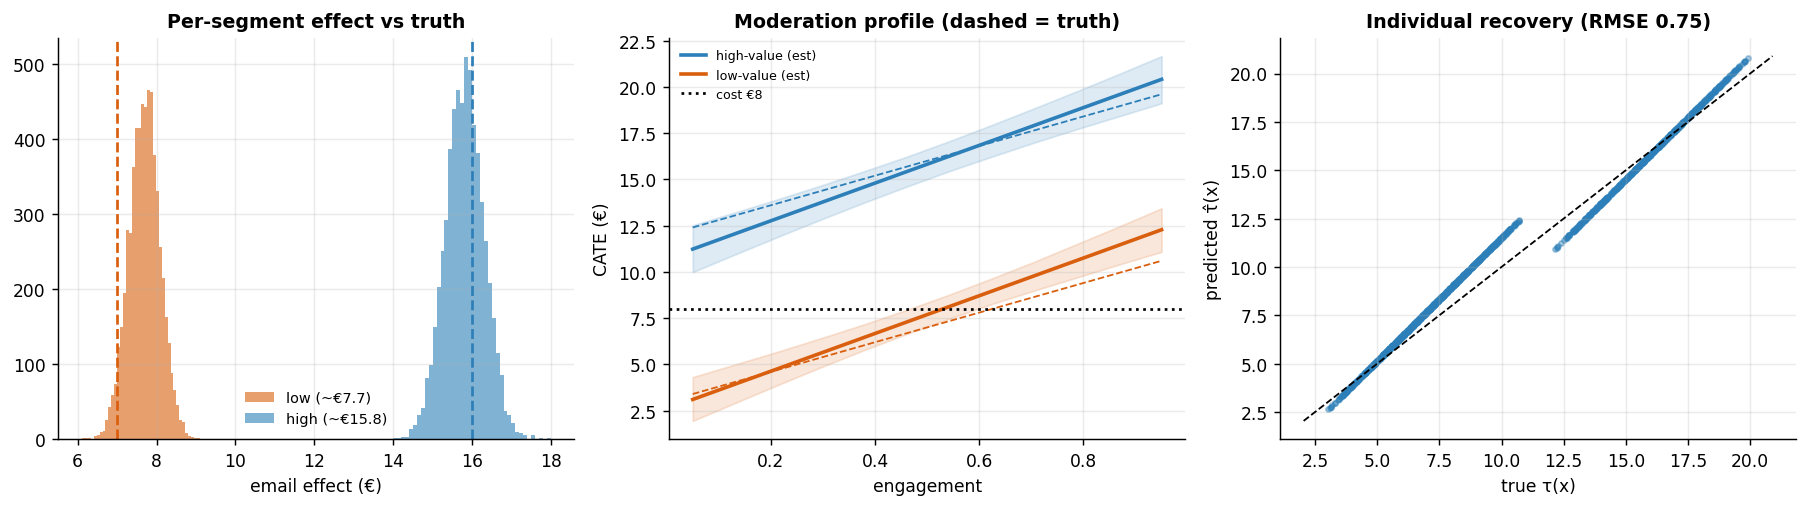

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# (1) segment posteriors vs truth
lo_d, hi_d = cate_low.draws(), cate_high.draws()
ax[0].hist(lo_d, bins=40, color=plots.ORANGE, alpha=0.6, label=f"low (~€{lo_d.mean():.1f})")
ax[0].hist(hi_d, bins=40, color=plots.BLUE, alpha=0.6, label=f"high (~€{hi_d.mean():.1f})")
ax[0].axvline(true_effect["low"], color=plots.ORANGE, ls="--"); ax[0].axvline(true_effect["high"], color=plots.BLUE, ls="--")
ax[0].set_xlabel("email effect (€)"); ax[0].set_title("Per-segment effect vs truth"); ax[0].legend(frameon=False, fontsize=8)
# (2) continuous moderation profile
eng_grid = np.linspace(0.05, 0.95, 12)
for hv, col, lab in [(1.0, plots.BLUE, "high"), (0.0, plots.ORANGE, "low")]:
    means, los, his = [], [], []
    for g in eng_grid:
        c = m.cate("spend", "email", condition={"is_high": hv, "engagement": float(g)}, values=(0,1))
        d = c.draws(); means.append(d.mean()); los.append(np.quantile(d,.05)); his.append(np.quantile(d,.95))
    ax[1].plot(eng_grid, means, color=col, lw=2, label=f"{lab}-value (est)")
    ax[1].fill_between(eng_grid, los, his, color=col, alpha=0.15)
    true_line = 3 + 9*hv + 8*eng_grid
    ax[1].plot(eng_grid, true_line, color=col, ls="--", lw=1)
ax[1].axhline(COST, color="k", ls=":", label=f"cost €{COST:.0f}")
ax[1].set_xlabel("engagement"); ax[1].set_ylabel("CATE (€)"); ax[1].set_title("Moderation profile (dashed = truth)")
ax[1].legend(frameon=False, fontsize=7)
# (3) per-customer recovery: predicted τ̂(x) from the moderation coefficients vs true τ
post = idata.posterior
be = post["beta_spend"].sel(spend_predictors="email").values.ravel()
bev = post["beta_spend"].sel(spend_predictors="email:is_high").values.ravel()
beg = post["beta_spend"].sel(spend_predictors="email:engagement").values.ravel()
tau_hat = (be.mean() + bev.mean()*df.is_high.values + beg.mean()*df.engagement.values)
ax[2].scatter(df.tau, tau_hat, s=8, alpha=0.4, color=plots.BLUE)
lim = [df.tau.min()-1, df.tau.max()+1]; ax[2].plot(lim, lim, "k--", lw=1)
rmse = np.sqrt(np.mean((tau_hat - df.tau.values)**2))
ax[2].set_xlabel("true τ(x)"); ax[2].set_ylabel("predicted τ̂(x)"); ax[2].set_title(f"Individual recovery (RMSE {rmse:.2f})")
fig.tight_layout()

**How to read those three panels.** *Left* — the two segment-effect posteriors sit right on top of their
planted truths (dashed lines) and barely overlap, so the model both **recovers** the effects and **separates**
the segments. *Middle* — the estimated CATE (solid) tracks the true `3 + 9·is_high + 8·engagement` line
(dashed) across the whole engagement range: modelling the *continuous* moderator paid off, because the effect
clearly rises with engagement rather than being a flat per-segment number. Note where each line crosses the €8
cost line — that's the engagement level above which a customer becomes worth emailing. *Right* — predicted vs
true effect *per customer* hugs the 45° line (low RMSE), confirming recovery at the individual level, not just
on segment averages.

## 6 · Decide, in euros — segment rules, and what pooling costs

Now the payoff. First we turn the per-segment effects into concrete **send rules** using the honest
probability criterion from notebook 01 — target a segment only where **P(effect > cost) is high** (not merely
where the mean beats cost). Then we answer the question that justifies this whole analysis: **how much money
does segmenting actually make versus treating everyone as the pooled average?**

We compare four policies on the *known* per-customer truth (only possible in simulation), forming a ladder of
increasing sophistication: **pooled** (one all-or-nothing decision on the ATE) → **segment rules** (one
decision per segment) → **individual** (a per-customer decision on $\hat\tau(x)$) → **oracle** (the unbeatable
rule that knows every true effect). The gaps between the rungs are, literally, the euros that finer targeting
is worth.


   segment  effect  net_of_cost  P(effect>cost) action
 low-value    7.69        -0.31            0.21   SKIP
high-value   15.82         7.82            1.00   SEND

Realised profit by policy:
  pooled (by ATE)    €3,682
  segment rules      €4,602
  individual τ̂      €4,873
  oracle             €4,923

Moving from pooled to individual targeting is worth €1,191 (32% uplift).


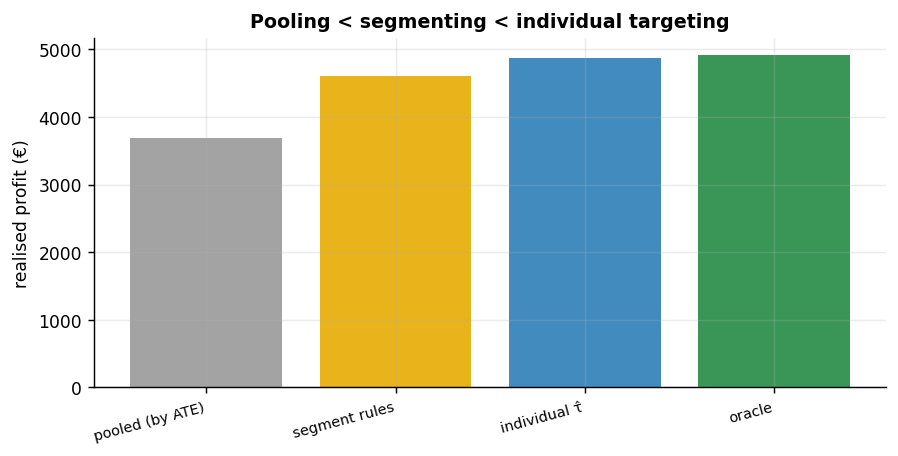

In [7]:
VALUE = 1.0
# segment decision table
rows = []
for name, c in [("low-value", cate_low), ("high-value", cate_high)]:
    d = c.draws(); p = (d > COST).mean()
    rows.append({"segment": name, "effect": round(d.mean(),2), "net_of_cost": round(d.mean()-COST,2),
                 "P(effect>cost)": round(p,2), "action": "SEND" if p>0.8 else ("SKIP" if p<0.5 else "TEST")})
tbl = pd.DataFrame(rows); print(tbl.to_string(index=False))

# four policies on the known per-customer truth: pooled < segmented < individual < oracle
gain = df.tau.values - COST
pooled_mask = np.full(len(df), ate.mean() > COST)                                  # treat-all-or-none on ATE
segmented_mask = np.where(df.is_high.values==1, cate_high.mean() > COST, cate_low.mean() > COST)
individual_mask = tau_hat > COST                                                    # per-customer τ̂ rule
oracle_mask = gain > 0
prof = {name: (mask * gain).sum() for name, mask in
        [("pooled (by ATE)", pooled_mask), ("segment rules", segmented_mask),
         ("individual τ̂", individual_mask), ("oracle", oracle_mask)]}
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(list(prof.keys()), list(prof.values()), color=[plots.GREY, plots.GOLD, plots.BLUE, plots.GREEN], alpha=0.9)
ax.set_ylabel("realised profit (€)"); ax.set_title("Pooling < segmenting < individual targeting")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8); fig.tight_layout()
print("\nRealised profit by policy:")
for k, v in prof.items(): print(f"  {k:18s} €{v:,.0f}")
print(f"\nMoving from pooled to individual targeting is worth €{prof['individual τ̂']-prof['pooled (by ATE)']:,.0f} "
      f"({(prof['individual τ̂']-prof['pooled (by ATE)'])/max(prof['pooled (by ATE)'],1):.0%} uplift).")

## 7 · Caveats

- **Heterogeneity is only as good as the moderator you measured.** If the real driver of
  differential response isn't `is_high`/`engagement` (or a proxy), the interaction won't catch it.
- **Interaction ≠ causing the moderator.** We're not claiming *making* someone high-value changes
  responsiveness — only that responsiveness *differs* across pre-existing segments.
- **Random slopes for many thin segments.** With dozens of small segments, replace the single
  interaction with partially-pooled random slopes so noisy segments borrow strength (see nb 03).
- **Same unconfoundedness caveat** — here email is randomized; observationally a hidden common
  cause of email and spend would bias every segment effect (see nb 05).
